In [307]:
# !pip install yfinance pandas numpy matplotlib seaborn plotly
# !pip install statsmodels pmdarima prophet scikit-learn
# !pip install tensorflow keras xgboost lightgbm
# !pip install nixtla

In [308]:
# Data handling
import pandas   as pd
import yfinance as yf
import numpy as np
from datetime import datetime, timedelta


from prophet import Prophet


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots


from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm


# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb


#Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, MultiHeadAttention, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [309]:
from nixtla import NixtlaClient

#### Get Data

In [ ]:

ticker    = 'AAPL'
stock     = yf.Ticker(ticker)
data      = stock.history(period="5y")

data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-02-04 00:00:00-05:00,132.681586,133.752374,131.016975,133.742645,84183100,0.000,0.0
2021-02-05 00:00:00-05:00,133.903453,133.971689,132.450837,133.328247,75693800,0.205,0.0
2021-02-08 00:00:00-05:00,132.616625,133.523297,131.534478,133.474548,71297200,0.000,0.0
2021-02-09 00:00:00-05:00,133.191786,134.420178,132.441118,132.597092,76774200,0.000,0.0
2021-02-10 00:00:00-05:00,133.055290,133.552502,131.027482,131.992645,73046600,0.000,0.0


In [311]:
# Lets  Use Close price for forecasting


df         = data[['Close']].copy()
df.columns = ['price']
df = df.asfreq("B")
df         = df.dropna()

print(f"\nData shape: {df.shape}")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
print(f"Total days: {len(df)} days")
print(f"\nFirst few rows:")
df.head()


Data shape: (1255, 1)
Date range: 2021-02-04 00:00:00-05:00 to 2026-02-03 00:00:00-05:00
Total days: 1255 days

First few rows:


,price
Date,
2021-02-04 00:00:00-05:00,133.742645
2021-02-05 00:00:00-05:00,133.328247
2021-02-08 00:00:00-05:00,133.474548
2021-02-09 00:00:00-05:00,132.597092
2021-02-10 00:00:00-05:00,131.992645


In [ ]:
# Lets  visualize the data


fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index, y=df['price'], mode='lines', name='Close Price'))

fig.update_layout(
    title=f'{ticker} Stock Price - Historical Data',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    height=500
)
fig.show()

### 1. Helper Functions / Preparation of the data

In [ ]:
# Check for stationarity using Augmented Dickey-Fuller test


def adf_test(series, name=''):
    
    result = adfuller(series.dropna())

    print(f'  ADF Test for {name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    print(f'  Critical Values:')

    for key, value in result[4].items():
        print(f'    {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print(f" Series is stationary (reject null hypothesis)\n")
    else:
        print(f" Series is non-stationary (fail to reject null hypothesis)\n")
    
    return result[1] <= 0.05


# Apply the method 

is_stationary = adf_test(df['price'], 'Original Series')

ADF Test for Original Series:
  ADF Statistic: -0.8425
  p-value: 0.8063
  Critical Values:
    1%: -3.4356
    5%: -2.8638
    10%: -2.5680
 Series is non-stationary (fail to reject null hypothesis)



Why do we did to check for stationarity??

A stationary time series has statistical properties—such as mean, variance, and autocovariance—that remain constant over time

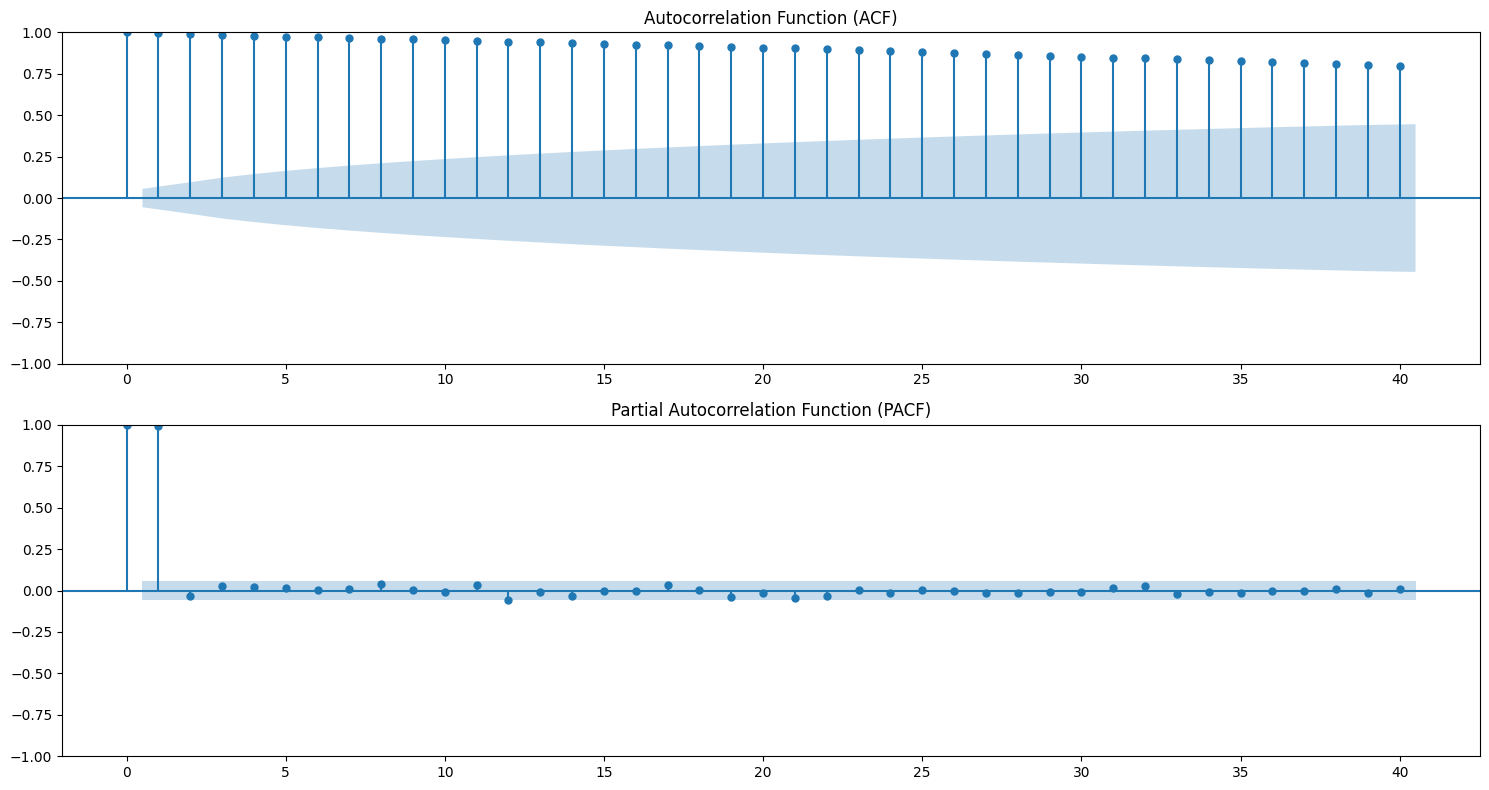

In [ ]:
# Plot ACF and PACF

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

plot_acf(df['price'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['price'].dropna(), lags=40, ax=axes[1])



axes[0].set_title('Autocorrelation Function (ACF)')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

How do you read the PACF and ACF Plots??

**Train-Test Split**   >..    Lets use the last 30 days as our test set to validate all models before forecasting the next 30 days.

In [ ]:
# Split data into train and test (last 30 days for testing)

test_size   = 30
train_data  = df[:-test_size].copy()
test_data   = df[-test_size:].copy()

print(f"Training set: {len(train_data)} days ({train_data.index[0]} to {train_data.index[-1]})")
print(f"Test set:     {len(test_data)} days ({test_data.index[0]} to {test_data.index[-1]})")

Training set: 1225 days (2021-02-04 00:00:00-05:00 to 2025-12-18 00:00:00-05:00)
Test set:     30 days (2025-12-19 00:00:00-05:00 to 2026-02-03 00:00:00-05:00)


**Evaluation Helper Functions**

In [ ]:
def calculate_metrics(y_true, y_pred, model_name='Model'):

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    metrics = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2
    }
    
    return metrics

def print_metrics(metrics):

    print(f"\n{'='*60}")
    print(f"Model: {metrics['Model']}")
    print(f"{'='*60}")
    print(f"  MAE:  {metrics['MAE']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  MAPE: {metrics['MAPE']:.2f}%")
    print(f"  R²:   {metrics['R²']:.4f}")
    print(f"{'='*60}")

# Initialize results storage
all_results   = []
all_forecasts = {}

### 1. STATISTICAL METHODS 
----

### A. AR (Autoregressive) Model
---
---

AR model predicts future values based on a linear combination of past values.

**Formula**: $y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$

In [ ]:

# Determine optimal lag using AIC

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)



ar_lags = range(1, 21)
ar_aic  = []

for lag in ar_lags:

    try:
        model     = AutoReg(train_data['price'], lags=lag)
        model_fit = model.fit()
        ar_aic.append(model_fit.aic)
    except:
        ar_aic.append(np.inf)

optimal_lag = ar_lags[np.argmin(ar_aic)]
print(f"Optimal lag selected: {optimal_lag}")



Optimal lag selected: 20


In [318]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")


# Fit AR model with optimal lag
ar_model = AutoReg(train_data['price'], lags=optimal_lag)
ar_fit  = ar_model.fit()

# Forecast test period
ar_test_forecast = ar_fit.forecast(steps=test_size)

# Calculate metrics
ar_metrics = calculate_metrics(test_data['price'].values, ar_test_forecast, 'AR Model')
print_metrics(ar_metrics)
all_results.append(ar_metrics)

# Forecast next 30 days
ar_full_model = AutoReg(df['price'], lags=optimal_lag)
ar_full_fit = ar_full_model.fit()
ar_future_forecast = ar_full_fit.forecast(steps=30)

# Store forecast
future_dates = pd.date_range(start=df.index[-1] + timedelta(days=1), periods=30, freq='B')
all_forecasts['AR'] = pd.Series(ar_future_forecast.array, index=future_dates)


Model: AR Model
  MAE:  11.1339
  RMSE: 13.9814
  MAPE: 4.35%
  R²:   -1.6835


**Moving Average Model**

In [319]:
# MA Model (using ARIMA with p=0, d=0)

ma_orders = range(1, 11)
ma_aic  = []

for q in ma_orders:
    try:
        model     = ARIMA(train_data['price'], order=(0, 0, q))
        model_fit = model.fit()
        ma_aic.append(model_fit.aic)
    except:
        ma_aic.append(np.inf)

optimal_q = ma_orders[np.argmin(ma_aic)]
print(f"Optimal MA order selected: {optimal_q}")


Optimal MA order selected: 8


In [320]:
# Fit MA model
ma_model = ARIMA(train_data['price'], order=(0, 0, optimal_q))
ma_fit = ma_model.fit()

# Forecast test period
ma_test_forecast = ma_fit.forecast(steps=test_size)

# Calculate metrics
ma_metrics = calculate_metrics(test_data['price'].values, ma_test_forecast, 'MA Model')
print_metrics(ma_metrics)
all_results.append(ma_metrics)

# Forecast next 30 days
ma_full_model = ARIMA(df['price'], order=(0, 0, optimal_q))
ma_full_fit = ma_full_model.fit()
ma_future_forecast = ma_full_fit.forecast(steps=30)

all_forecasts['MA'] = pd.Series(ma_future_forecast, index=future_dates)


Model: MA Model
  MAE:  71.1483
  RMSE: 74.2519
  MAPE: 27.19%
  R²:   -74.6853


**ARIMA MODELS**

In [321]:

# Use auto_arima to find best parameters

arima_auto = pm.auto_arima(
                        train_data['price'],
                        start_p=1, start_q=1,
                        max_p=5, max_q=5,
                        d=None, 
                        seasonal=False,
                        stepwise=True,
                        suppress_warnings=True,
                        error_action  ='ignore',
                        trace          =True
                    )

print(f"\nBest ARIMA order: {arima_auto.order}")
print(arima_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6239.012, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6237.368, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6237.072, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6237.143, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6237.009, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.380 seconds

Best ARIMA order: (0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1225
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3117.505
Date:                Wed, 04 Feb 2026   AIC                           6237.009
Time:                        15:41:22   BIC                           6242.119
Sample:                             0   HQIC                          6238.932
                               - 1225          

In [322]:
# Forecast test period
arima_test_forecast = arima_auto.predict(n_periods=test_size)

# Calculate metrics
arima_metrics = calculate_metrics(test_data['price'].values, arima_test_forecast, 'ARIMA Model')
print_metrics(arima_metrics)
all_results.append(arima_metrics)


# Forecast next 30 days
arima_full = pm.auto_arima(
    df['price'],
    start_p=arima_auto.order[0], start_q=arima_auto.order[2],
    max_p=arima_auto.order[0], max_q=arima_auto.order[2],
    d=arima_auto.order[1],
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)
arima_future_forecast = arima_full.predict(n_periods=30)

all_forecasts['ARIMA'] = pd.Series(arima_future_forecast, index=future_dates)


Model: ARIMA Model
  MAE:  10.1397
  RMSE: 12.9031
  MAPE: 3.97%
  R²:   -1.2855


**SARIMAX MODEL**


SARIMA extends ARIMA by adding seasonal components.

**Formula**: SARIMA(p, d, q)(P, D, Q, s) where:
- (p, d, q) = non-seasonal parameters
- (P, D, Q, s) = seasonal parameters
- s = seasonal period



In [323]:
# Use auto_arima with seasonal component
sarima_auto = pm.auto_arima(
                    train_data['price'],
                    start_p=1,
                    start_q=1,
                    max_p=3,
                    max_q=3,
                    d=None,
                    seasonal=True,
                    m=5,                    # Weekly seasonality (5 business days)
                    start_P=1,
                    start_Q=1,
                    max_P=2, max_Q=2,
                    D=None,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action='ignore',
                    trace=True
                )

print(f"\nBest SARIMA order: {sarima_auto.order}")
print(f"Best seasonal order: {sarima_auto.seasonal_order}")
print(sarima_auto.summary())



Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,0,1)[5] intercept   : AIC=6240.806, Time=0.88 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=6237.368, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=6238.292, Time=0.16 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=6238.257, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=6237.009, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=6238.525, Time=0.09 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=6238.426, Time=0.11 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=6239.058, Time=0.34 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=6237.072, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=6237.143, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=6239.012, Time=0.19 sec

Best model:  ARIMA(0,1,0)(0,0,0)[5]          
Total fit time: 2.185 seconds

Best SARIMA order: (0, 1, 0)
Best seasonal order: (0, 0, 0, 5)
                               SARIMAX Results                                
Dep. Variab

In [324]:
# Forecast test period
sarima_test_forecast = sarima_auto.predict(n_periods=test_size)

# Calculate metrics
sarima_metrics = calculate_metrics(test_data['price'].values, sarima_test_forecast, 'SARIMA Model')
print_metrics(sarima_metrics)
all_results.append(sarima_metrics)

# Forecast next 30 days
sarima_full = pm.auto_arima(
    df['price'],
    start_p=sarima_auto.order[0],
    start_q=sarima_auto.order[2],
    max_p=sarima_auto.order[0],
    max_q=sarima_auto.order[2],
    d=sarima_auto.order[1],
    seasonal=True,
    m=5,
    start_P=sarima_auto.seasonal_order[0],
    start_Q=sarima_auto.seasonal_order[2],
    max_P=sarima_auto.seasonal_order[0],
    max_Q=sarima_auto.seasonal_order[2],
    D=sarima_auto.seasonal_order[1],
    stepwise=True,
    suppress_warnings=True
)
sarima_future_forecast = sarima_full.predict(n_periods=30)

all_forecasts['SARIMA'] = pd.Series(sarima_future_forecast.array, index=future_dates)


Model: SARIMA Model
  MAE:  10.1397
  RMSE: 12.9031
  MAPE: 3.97%
  R²:   -1.2855


**SARIMAX Model**

SARIMAX extends SARIMA by including exogenous variables.

We'll create features like moving averages and lagged returns as exogenous variables.

In [ ]:

# Create exogenous variables
def create_exog_features(data):
    df_exog =               pd.DataFrame(index=data.index)
    df_exog['ma_7']        = data['price'].rolling(window=7).mean()
    df_exog['ma_21']       = data['price'].rolling(window=21).mean()
    df_exog['returns']     = data['price'].pct_change()
    df_exog['volatility']  = data['price'].rolling(window=21).std()
    return df_exog.bfill()

# Create exogenous features for train and test
train_exog = create_exog_features(train_data)
test_exog = create_exog_features(test_data)
full_exog = create_exog_features(df)

# Use SARIMA parameters from previous model
sarimax_model = SARIMAX(
                    train_data['price'],
                    exog       =     train_exog,
                    order            =sarima_auto.order,
                    seasonal_order   =sarima_auto.seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                 1225
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2562.098
Date:                Wed, 04 Feb 2026   AIC                           5134.197
Time:                        15:41:24   BIC                           5159.742
Sample:                             0   HQIC                          5143.810
                               - 1225                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma_7           0.9355      0.043     21.602      0.000       0.851       1.020
ma_21          0.1008      0.099      1.022      0.307      -0.093       0.294
returns       85.3010      0.935     91.223      0.0

In [ ]:
# Forecast test period
sarimax_test_forecast = sarimax_fit.forecast(steps=test_size, exog=test_exog)

# Calculate metrics
sarimax_metrics = calculate_metrics(test_data['price'].values, sarimax_test_forecast, 'SARIMAX Model')
print_metrics(sarimax_metrics)
all_results.append(sarimax_metrics)

# Forecast next 30 days
future_exog = pd.DataFrame(index=future_dates)
for col in full_exog.columns:
    future_exog[col] = full_exog[col].iloc[-1]  # Use last known value

    sarimax_full_model = SARIMAX(
                            df['price'],
                            exog=full_exog,
                            order=sarima_auto.order,
                            seasonal_order=sarima_auto.seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
sarimax_full_fit = sarimax_full_model.fit(disp=False)
sarimax_future_forecast = sarimax_full_fit.forecast(steps=30, exog=future_exog)

all_forecasts['SARIMAX'] = pd.Series(sarimax_future_forecast.array, index=future_dates)


Model: SARIMAX Model
  MAE:  4.7690
  RMSE: 5.7787
  MAPE: 1.81%
  R²:   0.5416


## Machine Learning Models

We'll create lag features, rolling statistics, and time-based features.

In [ ]:
def create_ml_features(data, lags=30):
    df_ml = pd.DataFrame(index=data.index)
    
    # Target variable
    df_ml['target'] = data['price']
    
    # Lag features
    for i in range(1, lags + 1):
        df_ml[f'lag_{i}'] = data['price'].shift(i)
    
    # Rolling statistics
    for window in [7, 14, 21, 30]:
        df_ml[f'rolling_mean_{window}'] = data['price'].rolling(window=window).mean()
        df_ml[f'rolling_std_{window}'] = data['price'].rolling(window=window).std()
        df_ml[f'rolling_min_{window}'] = data['price'].rolling(window=window).min()
        df_ml[f'rolling_max_{window}'] = data['price'].rolling(window=window).max()
    
    # Returns and momentum
    df_ml['returns']      = data['price'].pct_change()
    df_ml['returns_7']    = data['price'].pct_change(7)
    df_ml['returns_14']   = data['price'].pct_change(14)
    df_ml['returns_21']   = data['price'].pct_change(21)
    
    # Time-based features
    df_ml['day_of_week']    = data.index.dayofweek
    df_ml['day_of_month']   = data.index.day
    df_ml['month']          = data.index.month
    df_ml['quarter']        = data.index.quarter
    
    # Technical indicators
    df_ml['ema_12'] = data['price'].ewm(span=12).mean()
    df_ml['ema_26'] = data['price'].ewm(span=26).mean()
    df_ml['macd'] = df_ml['ema_12'] - df_ml['ema_26']
    
    # RSI
    delta  = data['price'].diff()
    gain  = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs    = gain / loss
    df_ml['rsi'] = 100 - (100 / (1 + rs))
    
    return df_ml.dropna()



In [328]:
# Create features
print("Creating features for ML models...")
ml_data = create_ml_features(df)

print(f"Total features created: {len(ml_data.columns) - 1}")  # -1 for target
print(f"Shape after feature engineering: {ml_data.shape}")
print(f"\nFeature list:")
print(ml_data.columns.tolist())

Creating features for ML models...
Total features created: 58
Shape after feature engineering: (1225, 59)

Feature list:
['target', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'lag_25', 'lag_26', 'lag_27', 'lag_28', 'lag_29', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_min_14', 'rolling_max_14', 'rolling_mean_21', 'rolling_std_21', 'rolling_min_21', 'rolling_max_21', 'rolling_mean_30', 'rolling_std_30', 'rolling_min_30', 'rolling_max_30', 'returns', 'returns_7', 'returns_14', 'returns_21', 'day_of_week', 'day_of_month', 'month', 'quarter', 'ema_12', 'ema_26', 'macd', 'rsi']


In [329]:
ml_data.head(3)

,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,returns_14,returns_21,day_of_week,day_of_month,month,quarter,ema_12,ema_26,macd,rsi
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-19 00:00:00-04:00,116.979088,117.505531,121.629410,122.419044,120.878693,117.992989,118.899651,116.969337,118.051483,113.440178,...,-0.061038,-0.074936,4,19,3,1,119.299152,120.658155,-1.359004,38.138657
2021-03-22 00:00:00-04:00,120.293762,116.979088,117.505531,121.629410,122.419044,120.878693,117.992989,118.899651,116.969337,118.051483,...,-0.013827,-0.049896,0,22,3,1,119.452902,120.628649,-1.175747,47.426337
2021-03-23 00:00:00-04:00,119.465088,120.293762,116.979088,117.505531,121.629410,122.419044,120.878693,117.992989,118.899651,116.969337,...,0.003933,-0.027460,1,23,3,1,119.454784,120.535078,-1.080294,50.764374


In [330]:
# Prepare ML train-test split
ml_train  = ml_data[:-test_size]
ml_test   = ml_data[-test_size:]

X_train = ml_train.drop('target', axis=1)
y_train = ml_train['target']

X_test = ml_test.drop('target', axis=1)
y_test = ml_test['target']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1195, 58)
X_test shape: (30, 58)


In [331]:
# Train Random Forest
rf_model = RandomForestRegressor(
                        n_estimators=200,
                        max_depth=15,
                        min_samples_split=5,
                        min_samples_leaf=2,
                        random_state=42,
                        n_jobs=-1
                    )

rf_model.fit(X_train, y_train)

# Forecast test period
rf_test_pred = rf_model.predict(X_test)

# Calculate metrics
rf_metrics = calculate_metrics(y_test.values, rf_test_pred, 'Random Forest')
print_metrics(rf_metrics)
all_results.append(rf_metrics)

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print("\nTop 10 Most Important Features:")
print(feature_importance)




Model: Random Forest
  MAE:  10.1435
  RMSE: 11.9628
  MAPE: 3.94%
  R²:   -0.9646

Top 10 Most Important Features:
           feature  importance
0            lag_1    0.558444
32   rolling_min_7    0.233185
33   rolling_max_7    0.097011
54          ema_12    0.043703
1            lag_2    0.038602
30  rolling_mean_7    0.012344
37  rolling_max_14    0.004858
46         returns    0.002772
2            lag_3    0.001412
41  rolling_max_21    0.000882


In [ ]:
# For future forecast, we need to iteratively predict

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")


def ml_recursive_forecast(model, last_data, n_steps=30):

    forecasts        = []
    current_features = last_data.copy()
    
    for _ in range(n_steps):

        # Predict next value
        next_pred = model.predict(current_features.values.reshape(1, -1))[0]
        forecasts.append(next_pred)
        
        # Update features (simplified - shift lags)  is a simplified approach in production you'd fully recalculate features
        lag_cols = [col for col in current_features.index if col.startswith('lag_')]

        for i in range(len(lag_cols) - 1, 0, -1):
            current_features[f'lag_{i+1}'] = current_features[f'lag_{i}']
        current_features['lag_1'] = next_pred
    
    return np.array(forecasts)


# Get last available features
last_features      = ml_data.drop('target', axis=1).iloc[-1]
rf_future_forecast = ml_recursive_forecast(rf_model, last_features, 30)

all_forecasts['Random Forest'] = pd.Series(rf_future_forecast, index=future_dates)


In [355]:
# Get last available features
last_features      = ml_data.drop('target', axis=1).iloc[-1]
rf_future_forecast = ml_recursive_forecast(rf_model, last_features, 30)

all_forecasts['Random Forest'] = pd.Series(rf_future_forecast, index=future_dates)

**XGBOOST**

In [333]:

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Forecast test period
xgb_test_pred = xgb_model.predict(X_test)

# Calculate metrics
xgb_metrics = calculate_metrics(y_test.values, xgb_test_pred, 'XGBoost')
print_metrics(xgb_metrics)
all_results.append(xgb_metrics)

# Future forecast
xgb_future_forecast = ml_recursive_forecast(xgb_model, last_features, 30)
all_forecasts['XGBoost'] = pd.Series(xgb_future_forecast, index=future_dates)


Model: XGBoost
  MAE:  6.3206
  RMSE: 7.7769
  MAPE: 2.46%
  R²:   0.1698


**LightGBM**

In [ ]:

# Train LightGBM
lgb_model = lgb.LGBMRegressor(
                    n_estimators=200,
                    max_depth=7,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    n_jobs=-1,
                    verbose=-1
                )

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

# Forecast test period
lgb_test_pred = lgb_model.predict(X_test)

# Calculate metrics
lgb_metrics = calculate_metrics(y_test.values, lgb_test_pred, 'LightGBM')
print_metrics(lgb_metrics)
all_results.append(lgb_metrics)

# Future forecast
lgb_future_forecast = ml_recursive_forecast(lgb_model, last_features, 30)
all_forecasts['LightGBM'] = pd.Series(lgb_future_forecast, index=future_dates)


Model: LightGBM
  MAE:  6.2261
  RMSE: 8.3413
  MAPE: 2.43%
  R²:   0.0449


### FACEBOOK PROPHET MODEL

Prophet is designed for forecasting time series with strong seasonal patterns and handles holidays/events well.

In [335]:

# Prepare data for Prophet (requires 'ds' and 'y' columns)


prophet_train = pd.DataFrame({
                        'ds': train_data.index,
                        'y': train_data['price'].values
                    })

prophet_train['ds'] = pd.to_datetime(prophet_train['ds']).dt.date

prophet_test = pd.DataFrame({
                        'ds': test_data.index,
                        'y': test_data['price'].values
                    })

prophet_test['ds'] = pd.to_datetime(prophet_test['ds']).dt.date


In [336]:
# Initialize and fit Prophet model
prophet_model = Prophet(
                    daily_seasonality=True,
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    changepoint_prior_scale=0.05,
                    seasonality_prior_scale=10,
                    seasonality_mode='multiplicative'
                )

DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path


In [337]:
prophet_model.fit(prophet_train)

# Forecast test period
prophet_test_forecast = prophet_model.predict(prophet_test[['ds']])

# Calculate metrics
prophet_metrics = calculate_metrics(
                    prophet_test['y'].values,
                    prophet_test_forecast['yhat'].values,
                    'Prophet'
                )

print_metrics(prophet_metrics)
all_results.append(prophet_metrics)

DEBUG:cmdstanpy:input tempfile: C:\Users\Lbundi\AppData\Local\Temp\tmp3zbvvwnr\vo_fgkbk.json
DEBUG:cmdstanpy:input tempfile: C:\Users\Lbundi\AppData\Local\Temp\tmp3zbvvwnr\i2ufso5f.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\Lbundi\\Desktop\\Strathmore Lectures\\Fcast\\tms_env\\.venv\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=36901', 'data', 'file=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\vo_fgkbk.json', 'init=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\i2ufso5f.json', 'output', 'file=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\prophet_modelncs4ikcl\\prophet_model-20260204154129.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:41:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:41:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Model: Prophet
  MAE:  3.5835
  RMSE: 4.7950
  MAPE: 1.38%
  R²:   0.6844


In [338]:
# Forecast next 30 days
prophet_full = Prophet(
                    daily_seasonality=True,
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    changepoint_prior_scale=0.05,
                    seasonality_prior_scale=10,
                    seasonality_mode='multiplicative'
                )

prophet_full_data = pd.DataFrame({
                        'ds': df.index,
                        'y': df['price'].values
                    })

prophet_full_data['ds']= pd.DatetimeIndex(prophet_full_data['ds']).tz_localize(None)  # another way to remove timezone
prophet_full.fit(prophet_full_data)

# Create future dataframe
future = prophet_full.make_future_dataframe(periods=30, freq='B')
prophet_future_forecast_df = prophet_full.predict(future)

# Extract future predictions
prophet_future_forecast = prophet_future_forecast_df.tail(30)['yhat'].values
all_forecasts['Prophet'] = pd.Series(prophet_future_forecast, index=future_dates)


DEBUG:cmdstanpy:cmd: where.exe tbb.dll
cwd: None
DEBUG:cmdstanpy:TBB already found in load path
DEBUG:cmdstanpy:input tempfile: C:\Users\Lbundi\AppData\Local\Temp\tmp3zbvvwnr\gge76hqf.json
DEBUG:cmdstanpy:input tempfile: C:\Users\Lbundi\AppData\Local\Temp\tmp3zbvvwnr\qf1pxu0p.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['C:\\Users\\Lbundi\\Desktop\\Strathmore Lectures\\Fcast\\tms_env\\.venv\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=28852', 'data', 'file=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\gge76hqf.json', 'init=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\qf1pxu0p.json', 'output', 'file=C:\\Users\\Lbundi\\AppData\\Local\\Temp\\tmp3zbvvwnr\\prophet_model40nf1gf6\\prophet_model-20260204154132.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:41:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:41:34 - cmdsta

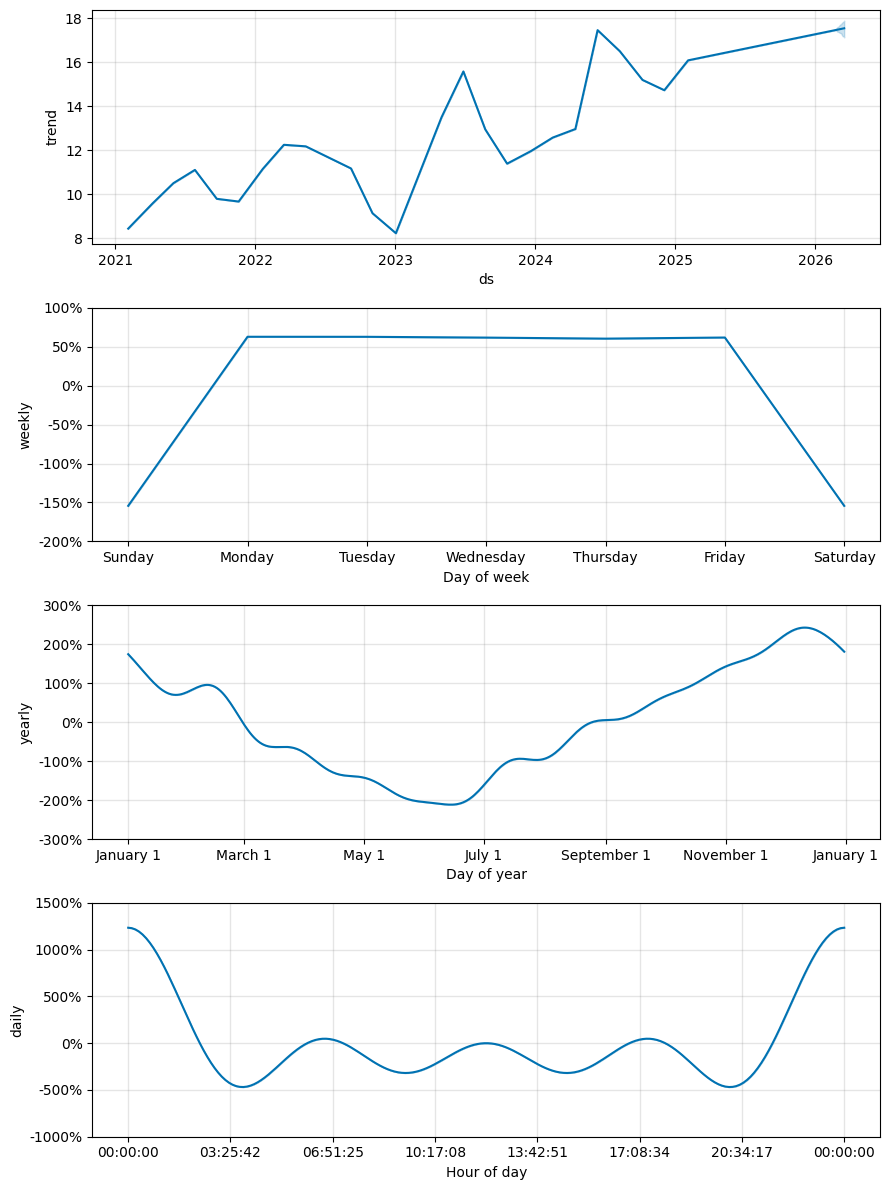

In [339]:
# Plot Prophet components


fig = prophet_full.plot_components(prophet_future_forecast_df)
plt.tight_layout()
plt.show()

### Deep Learning

In [ ]:
def create_sequences(data, seq_length=60):
    """
    Create sequences for LSTM/GRU training
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Normalize data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['price']].values)




# Create sequences
seq_length = 60
X_seq, y_seq = create_sequences(scaled_data, seq_length)

# Split into train and test
train_size = len(X_seq) - test_size
X_train_dl = X_seq[:train_size]
y_train_dl = y_seq[:train_size]
X_test_dl = X_seq[train_size:]
y_test_dl = y_seq[train_size:]

print(f"Deep Learning data shapes:")
print(f"X_train: {X_train_dl.shape}")
print(f"y_train: {y_train_dl.shape}")
print(f"X_test: {X_test_dl.shape}")
print(f"y_test: {y_test_dl.shape}")

Deep Learning data shapes:
X_train: (1165, 60, 1)
y_train: (1165, 1)
X_test: (30, 60, 1)
y_test: (30, 1)


In [ ]:


# Build LSTM model
lstm_model = Sequential([
                    LSTM(128, return_sequences=True, input_shape=(seq_length, 1)),
                    Dropout(0.2),
                    LSTM(64, return_sequences=True),
                    Dropout(0.2),
                    LSTM(32),
                    Dropout(0.2),
                    Dense(16, activation='relu'),
                    Dense(1)
                ])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Callbacks
early_stop  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

# Train
history_lstm = lstm_model.fit(
        X_train_dl, 
        y_train_dl,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )



C:\Users\Lbundi\Desktop\Strathmore Lectures\Fcast\tms_env\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - loss: 0.0338 - mae: 0.1306 - val_loss: 0.0141 - val_mae: 0.1060 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0065 - mae: 0.0615 - val_loss: 0.0244 - val_mae: 0.1481 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0045 - mae: 0.0515 - val_loss: 0.0096 - val_mae: 0.0887 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - loss: 0.0041 - mae: 0.0497 - val_loss: 0.0081 - val_mae: 0.0805 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - loss: 0.0039 - mae: 0.0469 - val_loss: 0.0075 - val_mae: 0.0760 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - loss: 0.0037 - mae: 0.0469 - val_loss: 0.0189 - val_mae: 0.1279 - learning_rate: 0.0010
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0038 - mae: 0.0470 - val_loss: 0.0018 - val_mae: 0.0346 - learning_rate: 0.0010
E


Model: LSTM
  MAE:  8.9875
  RMSE: 10.5193
  MAPE: 3.48%
  R²:   -0.5190


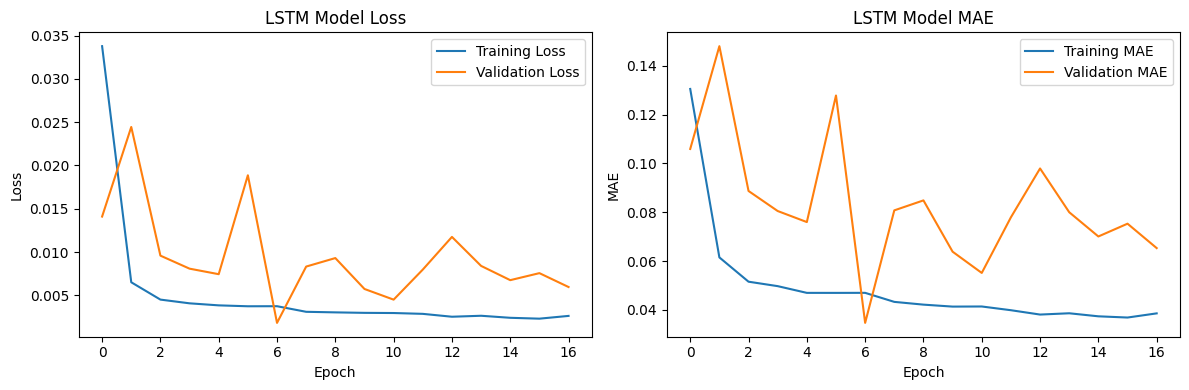

In [342]:
# Forecast test period
lstm_test_pred_scaled = lstm_model.predict(X_test_dl, verbose=0)
lstm_test_pred = scaler.inverse_transform(lstm_test_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test_dl)

# Calculate metrics
lstm_metrics = calculate_metrics(y_test_actual.flatten(), lstm_test_pred.flatten(), 'LSTM')
print_metrics(lstm_metrics)
all_results.append(lstm_metrics)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['mae'], label='Training MAE')
plt.plot(history_lstm.history['val_mae'], label='Validation MAE')
plt.title('LSTM Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Future forecast
def dl_recursive_forecast(model, last_sequence, scaler, n_steps=30):

    forecasts = []
    current_seq = last_sequence.copy()
    
    for _ in range(n_steps):

        # Predict next value
        next_pred_scaled = model.predict(current_seq.reshape(1, seq_length, 1), verbose=0)
        next_pred       = scaler.inverse_transform(next_pred_scaled)[0, 0]
        forecasts.append(next_pred)
        
        # Update sequence
        current_seq = np.append(current_seq[1:], next_pred_scaled)
    
    return np.array(forecasts)



In [ ]:
last_sequence         = scaled_data[-seq_length:].flatten()
lstm_future_forecast  = dl_recursive_forecast(lstm_model, last_sequence, scaler, 30)
all_forecasts['LSTM'] = pd.Series(lstm_future_forecast, index=future_dates)

**GRU Model**

GRU (Gated Recurrent Unit) is similar to LSTM but with a simpler architecture.

In [ ]:
# Build GRU model
gru_model = Sequential([
                GRU(128, return_sequences=True, input_shape=(seq_length, 1)),  #It tells this layer to pass the entire processed sequence to the next layer
                Dropout(0.2),
                GRU(64, return_sequences=True),
                Dropout(0.2),
                GRU(32),
                Dropout(0.2),
                Dense(16, activation='relu'),
                Dense(1)
            ])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history_gru = gru_model.fit(
                    X_train_dl, y_train_dl,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.1,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1
                )



C:\Users\Lbundi\Desktop\Strathmore Lectures\Fcast\tms_env\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - loss: 0.0236 - mae: 0.1092 - val_loss: 0.0267 - val_mae: 0.1556 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0035 - mae: 0.0441 - val_loss: 0.0060 - val_mae: 0.0692 - learning_rate: 0.0010
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0029 - mae: 0.0393 - val_loss: 0.0087 - val_mae: 0.0852 - learning_rate: 0.0010
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0027 - mae: 0.0387 - val_loss: 0.0060 - val_mae: 0.0695 - learning_rate: 0.0010
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0025 - mae: 0.0372 - val_loss: 0.0134 - val_mae: 0.1088 - learning_rate: 0.0010
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0024 - mae: 0.0354 - val_loss: 0.0059 - val_mae: 0.0685 - learning_rate: 5.0000e-04
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0022 - mae: 0.0345 - val_loss: 0.0083 - val_mae: 0.0832 - learning_rate: 5.0000e

In [345]:
# Forecast test period
gru_test_pred_scaled = gru_model.predict(X_test_dl, verbose=0)
gru_test_pred        = scaler.inverse_transform(gru_test_pred_scaled)

# Calculate metrics
gru_metrics = calculate_metrics(y_test_actual.flatten(), gru_test_pred.flatten(), 'GRU')
print_metrics(gru_metrics)
all_results.append(gru_metrics)

# Future forecast
gru_future_forecast = dl_recursive_forecast(gru_model, last_sequence, scaler, 30)
all_forecasts['GRU'] = pd.Series(gru_future_forecast, index=future_dates)


Model: GRU
  MAE:  28.2879
  RMSE: 28.9488
  MAPE: 10.73%
  R²:   -10.5043


### Model Comparison - Test Set Performance

In [346]:
# comprehensive results dataframe

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('RMSE')

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON - TEST SET PERFORMANCE")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


best_model = results_df.iloc[0]['Model']
print(f"\nBEST MODEL: {best_model} (Lowest RMSE)")


COMPREHENSIVE MODEL COMPARISON - TEST SET PERFORMANCE
        Model       MAE      RMSE      MAPE         R²
      Prophet  3.583532  4.794994  1.380883   0.684374
SARIMAX Model  4.769029  5.778742  1.807682   0.541581
      XGBoost  6.320618  7.776893  2.462800   0.169751
     LightGBM  6.226141  8.341278  2.429605   0.044873
         LSTM  8.987459 10.519260  3.477161  -0.519030
Random Forest 10.143518 11.962846  3.939977  -0.964559
  ARIMA Model 10.139669 12.903105  3.965984  -1.285517
 SARIMA Model 10.139669 12.903105  3.965984  -1.285517
     AR Model 11.133944 13.981438  4.351341  -1.683488
          GRU 28.287895 28.948849 10.730879 -10.504258
     MA Model 71.148346 74.251930 27.194989 -74.685294

BEST MODEL: Prophet (Lowest RMSE)


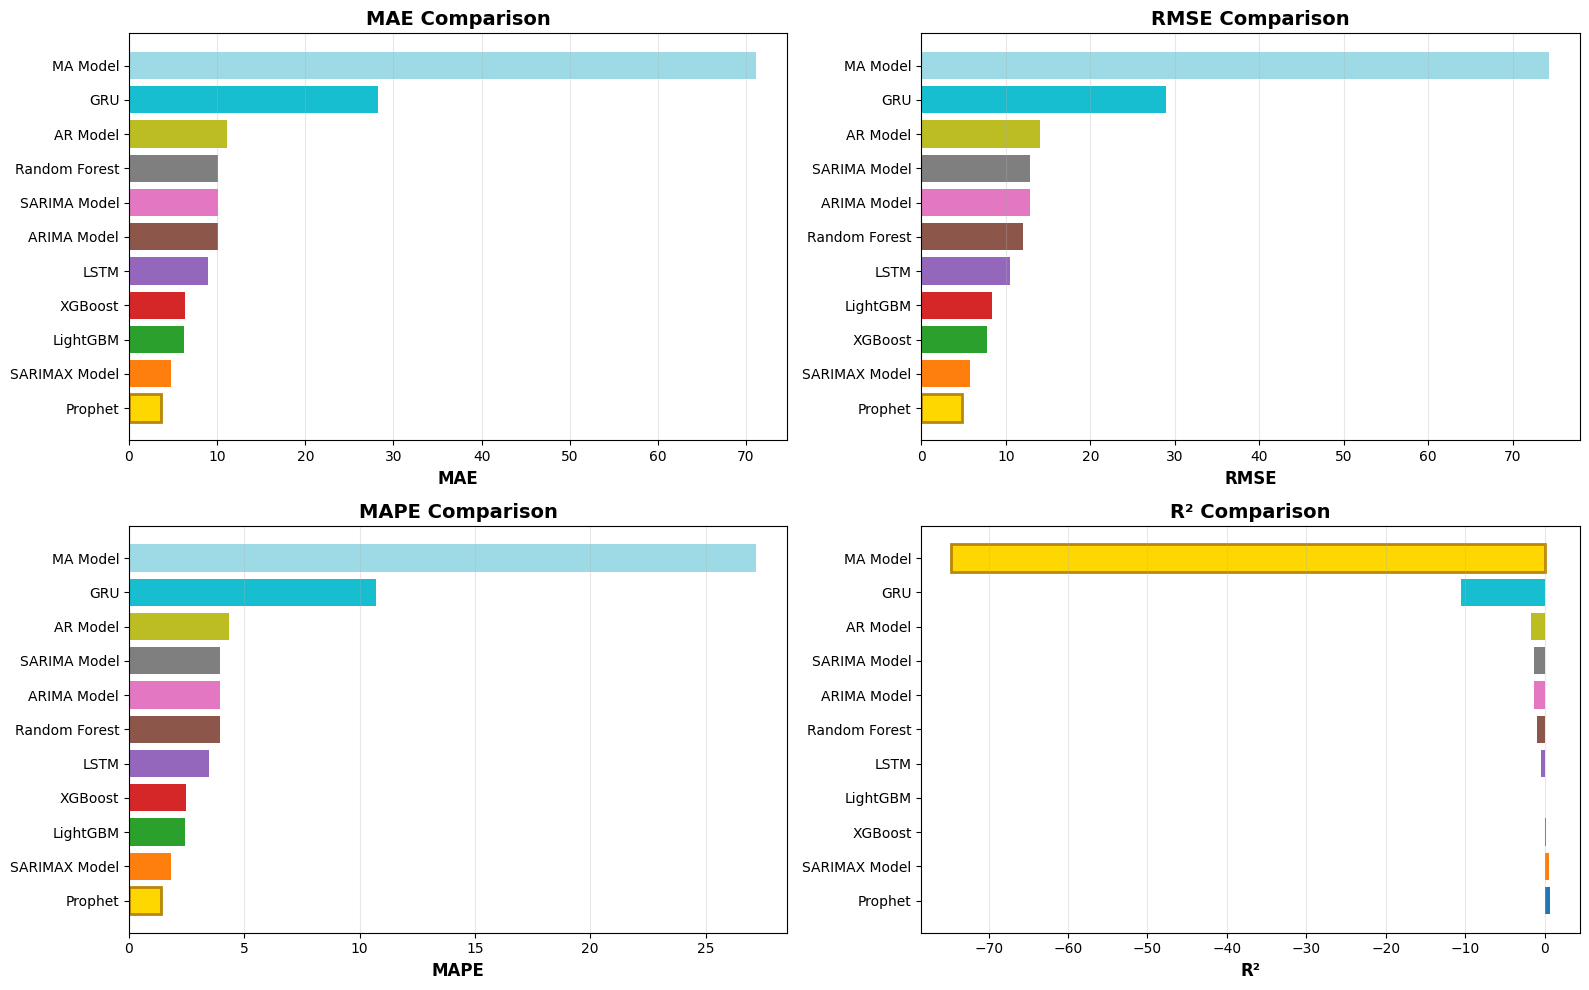

In [ ]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['MAE', 'RMSE', 'MAPE', 'R²']
colors        = plt.cm.tab20(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    sorted_data = results_df.sort_values(metric, ascending=(metric != 'R²'))
    
    bars = ax.barh(sorted_data['Model'], sorted_data[metric], color=colors)
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Highlight best model
    best_idx = 0 if metric != 'R²' else len(sorted_data) - 1
    bars[best_idx].set_color('gold')
    bars[best_idx].set_edgecolor('darkgoldenrod')
    bars[best_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

### Future Forecasts Visualization (30 Days)

In [348]:
# Create comprehensive forecast plot
fig = go.Figure()

# Historical data
fig.add_trace(go.Scatter(
    x=df.index[-320:],  # Last 90 days of history
    y=df['price'][-320:],
    mode='lines',
    name='Historical Data',
    line=dict(color='black', width=2)
))

# All forecasts
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 
          'pink', 'gray', 'olive', 'cyan', 'magenta', 'lime', 'navy']

for idx, (model_name, forecast) in enumerate(all_forecasts.items()):
    if not forecast.isna().all(): 
        fig.add_trace(go.Scatter(
            x=forecast.index,
            y=forecast.values,
            mode='lines+markers',
            name=model_name,
            line=dict(color=colors[idx % len(colors)], width=2),
            marker=dict(size=4)
        ))

fig.update_layout(
    title=f'{ticker} Stock Price - 30-Day Forecast Comparison',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    height=600,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()

### Individual Model Forecast Plots

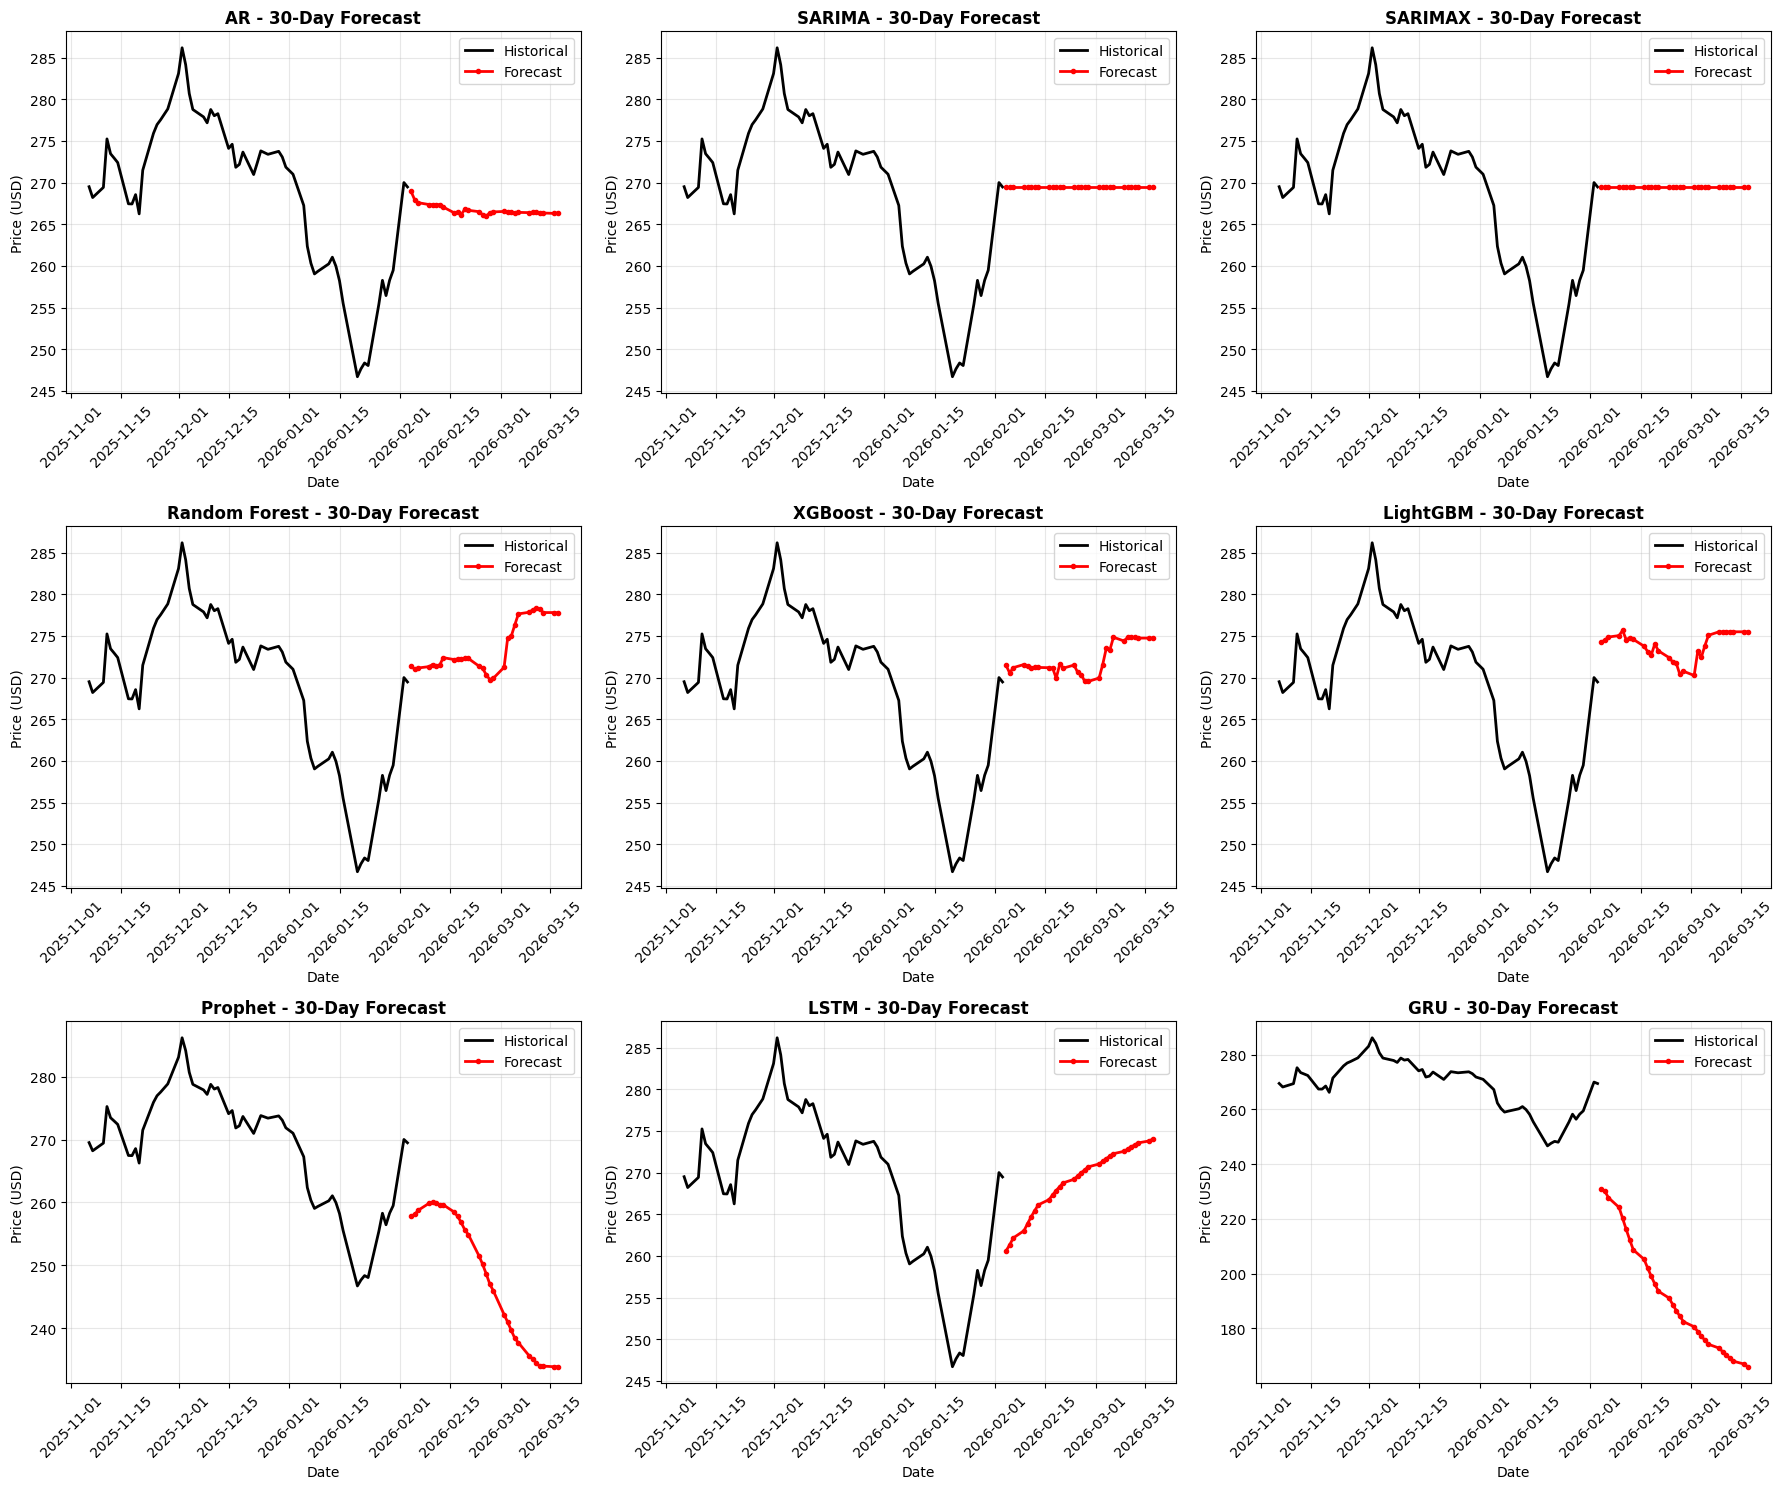

In [349]:
# Create individual plots for each model
n_models = len([f for f in all_forecasts.values() if not f.isna().all()])
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

plot_idx = 0
for model_name, forecast in all_forecasts.items():
    if not forecast.isna().all():
        ax = axes[plot_idx]
        
        # Plot historical
        ax.plot(df.index[-60:], df['price'][-60:], label='Historical', color='black', linewidth=2)
        
        # Plot forecast
        ax.plot(forecast.index, forecast.values, label='Forecast', 
               color='red', linewidth=2, marker='o', markersize=3)
        
        ax.set_title(f'{model_name} - 30-Day Forecast', fontsize=12, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price (USD)')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()